In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
annual_data = pd.read_csv("../data/cleaned/BunkerByCategoryLong.csv")
annual_data = annual_data.set_index("year")
annual_data

,Unnamed: 0,fuel_category,bunker_sales
year,,,
1995,0,Alternative,0.00
1995,1,LNG,0.00
1995,2,LSFO,0.00
1995,3,LSMGO,0.00
1995,4,MDO,700.10
...,...,...,...
2025,243,LSMGO,4251.65
2025,244,MDO,0.00
2025,245,MFO,22085.55


In [3]:
yearly = annual_data.groupby("year")["bunker_sales"].sum().reset_index()
yearly

,year,bunker_sales
0,1995,17489.20
1,1996,16938.48
2,1997,16940.75
3,1998,18063.82
4,1999,18891.20
5,2000,18650.79
6,2001,20351.67
7,2002,20096.38
8,2003,20808.97
9,2004,23566.87


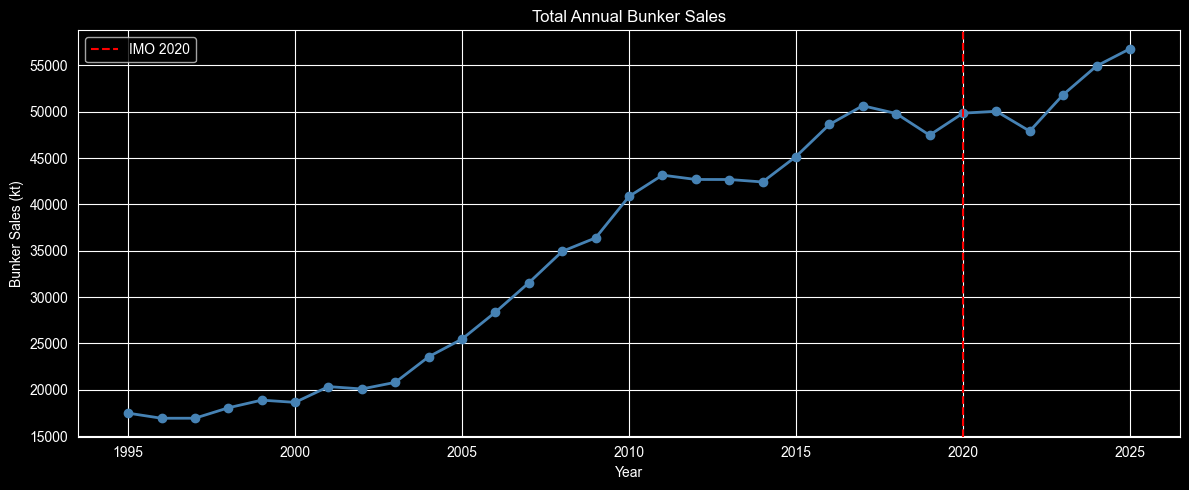

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly["year"], yearly["bunker_sales"], marker="o", color="steelblue", linewidth=2)
ax.axvline(2020, color="red", linestyle="--", linewidth=1.5, label="IMO 2020")
ax.set_xlabel("Year")
ax.set_ylabel("Bunker Sales (kt)")
ax.set_title("Total Annual Bunker Sales")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
yearly["yoy_growth"] = yearly["bunker_sales"].pct_change() * 100

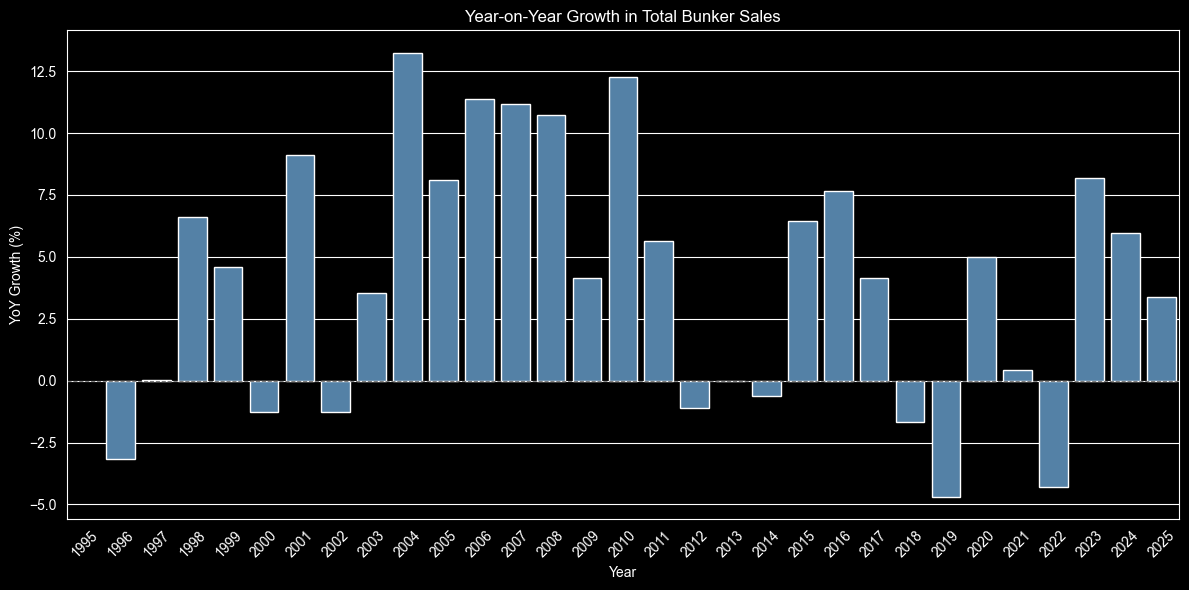

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=yearly, x="year", y="yoy_growth", ax=ax, color="steelblue")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth (%)")
ax.set_title("Year-on-Year Growth in Total Bunker Sales")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [7]:
annual_wide = pd.read_csv("../data/cleaned/BunkerByCategoryWide.csv")
annual_wide = annual_wide.set_index("year")

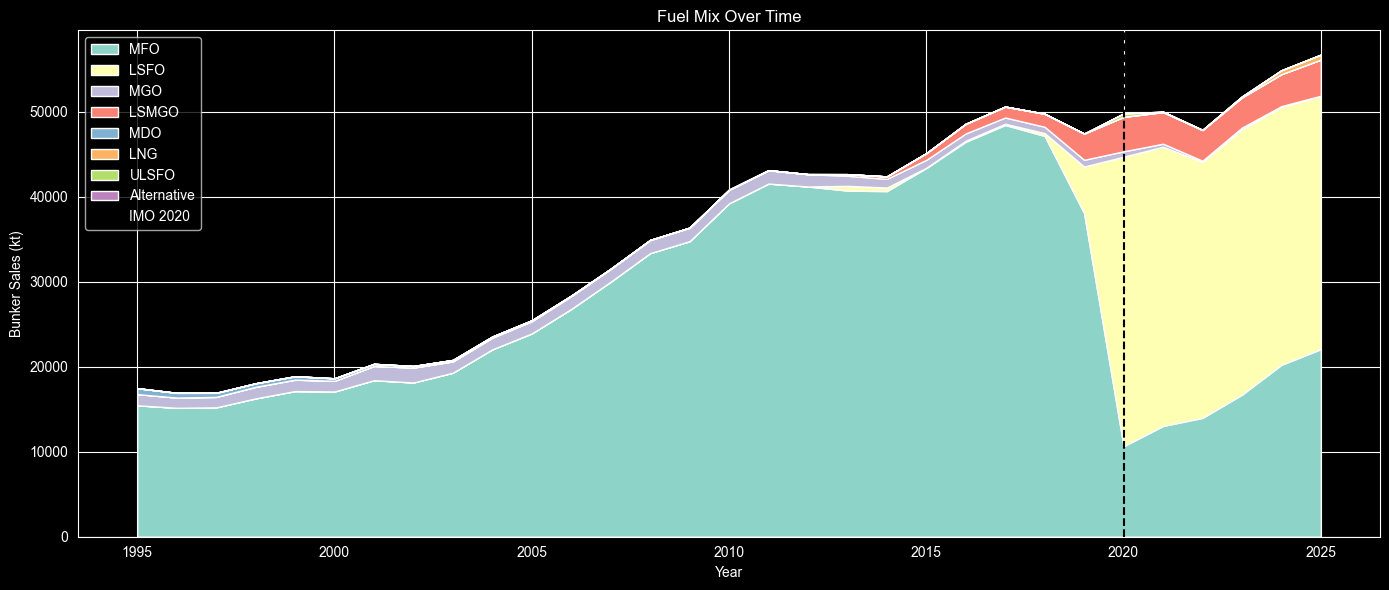

In [8]:
order = annual_wide.sum().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(annual_wide.index, [annual_wide[c] for c in order], labels=order)
ax.axvline(2020, color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('Bunker Sales (kt)')
ax.set_title('Fuel Mix Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


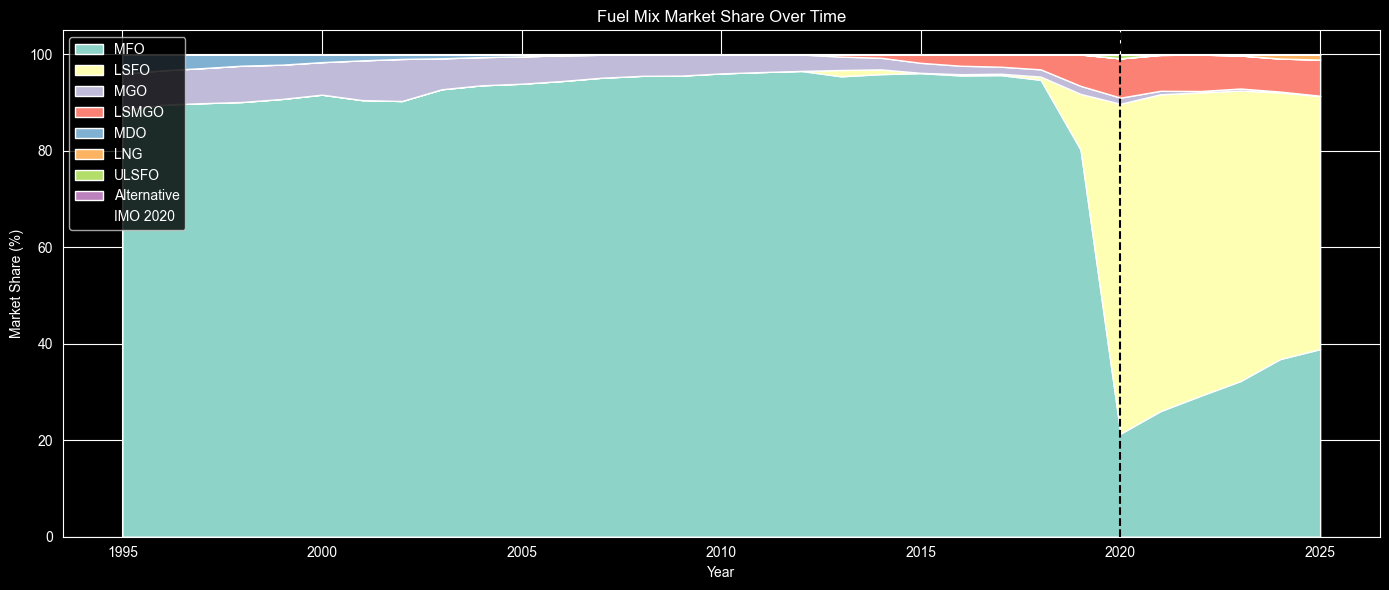

In [9]:
pct = annual_wide.div(annual_wide.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(pct.index, [pct[c] for c in order], labels=order)
ax.axvline(2020, color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('Market Share (%)')
ax.set_title('Fuel Mix Market Share Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()



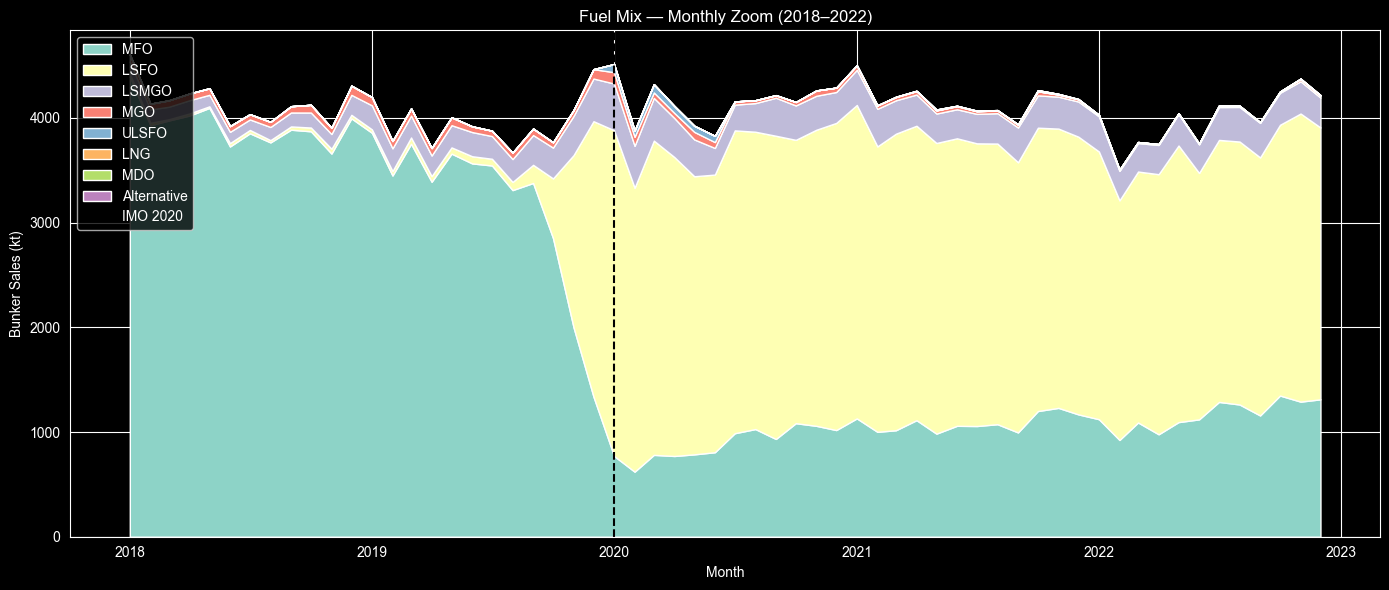

In [10]:
monthly_clean = pd.read_csv("../data/cleaned/BunkerByCategoryMonthly.csv", parse_dates=['month'])
monthly = monthly_clean.groupby(['month', 'fuel_category'])['bunker_sales'].sum().reset_index()
monthly_pivot = monthly.pivot_table(index='month', columns='fuel_category', values='bunker_sales', fill_value=0).sort_index()

zoom = monthly_pivot.loc['2018':'2022']
zoom_order = zoom.sum().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(zoom.index, [zoom[c] for c in zoom_order], labels=zoom_order)
ax.axvline(pd.Timestamp('2020-01-01'), color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Month')
ax.set_ylabel('Bunker Sales (kt)')
ax.set_title('Fuel Mix — Monthly Zoom (2018–2022)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
# CAGR for each fuel type — pre vs post IMO 2020
cagr_records = []
for fuel in annual_data["fuel_category"].unique():
    fuel_data = annual_data[annual_data["fuel_category"] == fuel].sort_index()
    annual = fuel_data.groupby(fuel_data.index)["bunker_sales"].sum()

    for period, subset in [("pre-IMO", annual[annual.index < 2020]), ("post-IMO", annual[annual.index >= 2020])]:
        subset = subset[subset > 0]
        if len(subset) > 1:
            years = subset.index[-1] - subset.index[0]
            cagr = (subset.iloc[-1] / subset.iloc[0]) ** (1 / years) - 1
            cagr_records.append({"fuel_category": fuel, "period": period, "cagr": cagr})
            print(f"{fuel} {period}: {cagr:.2%}")

cagr_df = pd.DataFrame(cagr_records)

Alternative post-IMO: 874.85%
LNG pre-IMO: 5.41%
LNG post-IMO: 84.61%
LSFO pre-IMO: 46.34%
LSFO post-IMO: -2.65%
LSMGO pre-IMO: 59.05%
LSMGO post-IMO: 0.92%
MDO pre-IMO: -24.75%
MDO post-IMO: 62.95%
MFO pre-IMO: 3.83%
MFO post-IMO: 15.70%
MGO pre-IMO: -2.10%
MGO post-IMO: -44.72%
ULSFO post-IMO: -56.11%


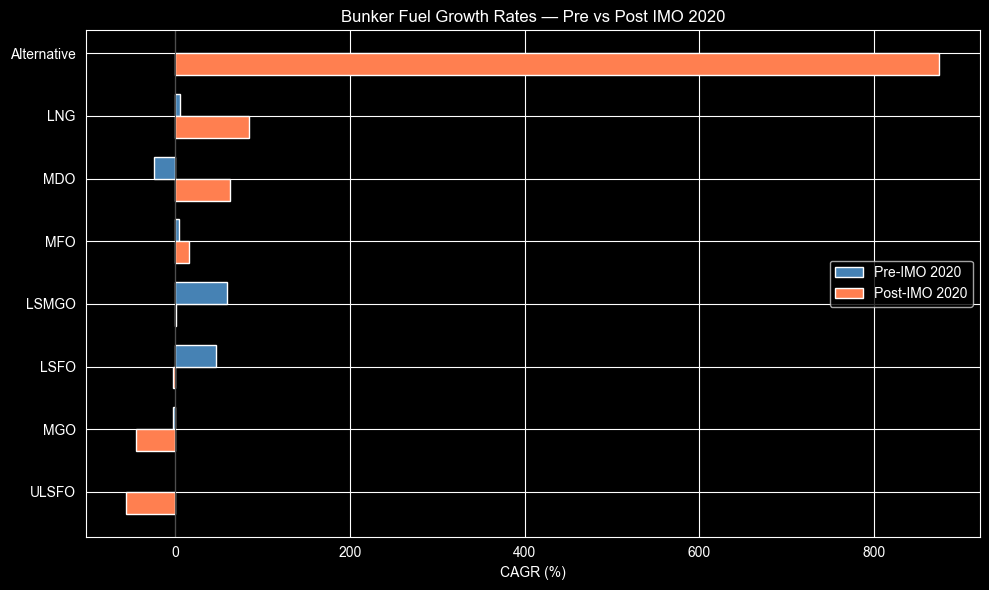

In [12]:
# Grouped horizontal bar chart — pre vs post IMO 2020 CAGR
pivot = cagr_df.pivot(index="fuel_category", columns="period", values="cagr").sort_values("post-IMO", na_position="first")

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(pivot))
bar_height = 0.35

ax.barh([i + bar_height / 2 for i in y], pivot.get("pre-IMO", pd.Series(dtype=float)).values * 100, bar_height, label="Pre-IMO 2020", color="steelblue")
ax.barh([i - bar_height / 2 for i in y], pivot.get("post-IMO", pd.Series(dtype=float)).values * 100, bar_height, label="Post-IMO 2020", color="coral")

ax.set_yticks(list(y))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("CAGR (%)")
ax.set_title("Bunker Fuel Growth Rates — Pre vs Post IMO 2020")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## 5. IMO 2020 Deep Dive — 2019 vs 2021 Fuel Mix

In [13]:
# 2019 vs 2021 annual totals by fuel category
compare_years = annual_data[annual_data.index.isin([2019, 2021])]
compare = compare_years.groupby([compare_years.index, "fuel_category"])["bunker_sales"].sum().unstack(fill_value=0)
compare = compare.T.sort_values(by=2019, ascending=False)

# Add market share columns
compare["share_2019"] = compare[2019] / compare[2019].sum() * 100
compare["share_2021"] = compare[2021] / compare[2021].sum() * 100
compare["share_change"] = compare["share_2021"] - compare["share_2019"]
compare

year,2019,2021,share_2019,share_2021,share_change
fuel_category,,,,,
MFO,38101.72,13034.92,80.274277,26.049006,-54.225271
LSFO,5479.12,32873.58,11.543636,65.694617,54.150981
LSMGO,3089.88,3722.02,6.509887,7.438091,0.928204
MGO,792.04,360.28,1.668703,0.719984,-0.948718
LNG,0.90,49.19,0.001896,0.098301,0.096405
MDO,0.76,0.00,0.001601,0.000000,-0.001601
Alternative,0.00,0.00,0.000000,0.000000,0.000000
ULSFO,0.00,0.00,0.000000,0.000000,0.000000


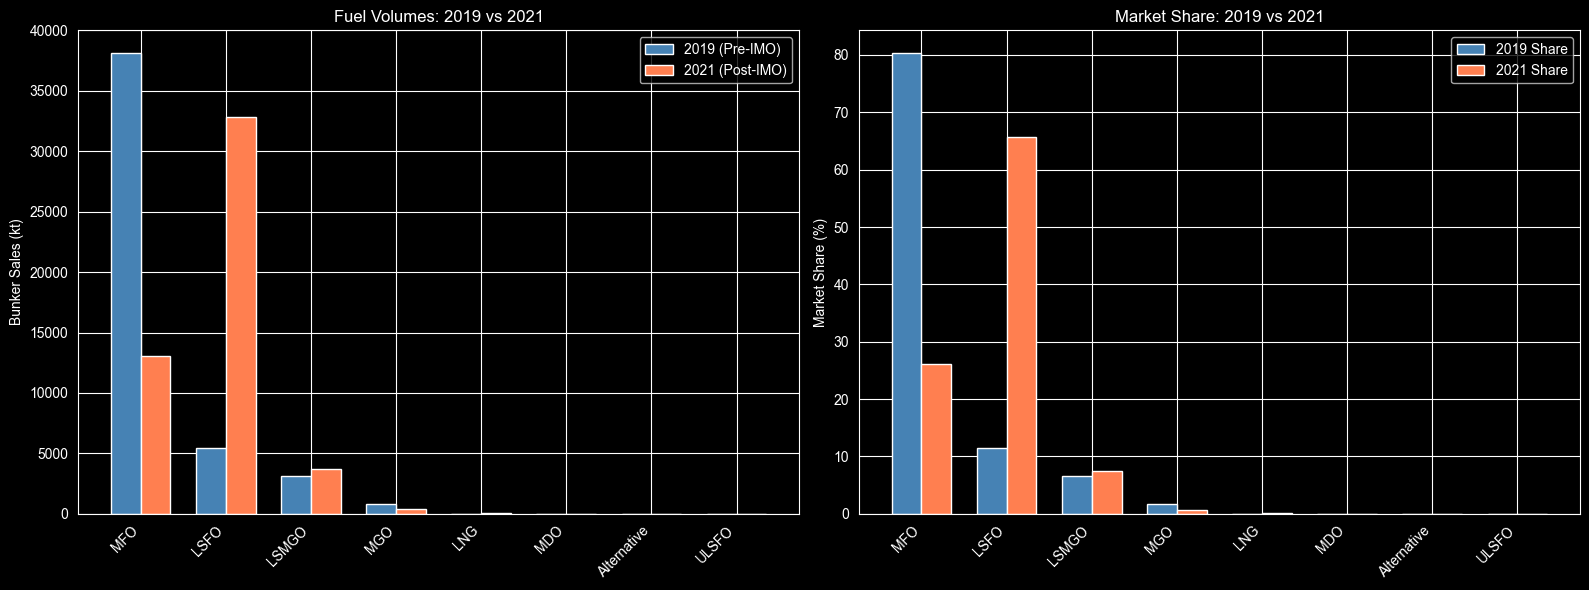

MFO: 80.3% → 26.0% (-54.2 pp)
LSFO: 11.5% → 65.7% (+54.2 pp)


In [14]:
# Before/after bar chart — 2019 vs 2021 absolute volumes
fuels = compare.index.tolist()
x = range(len(fuels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute volumes
ax = axes[0]
ax.bar([i - width/2 for i in x], compare[2019], width, label="2019 (Pre-IMO)", color="steelblue")
ax.bar([i + width/2 for i in x], compare[2021], width, label="2021 (Post-IMO)", color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(fuels, rotation=45, ha="right")
ax.set_ylabel("Bunker Sales (kt)")
ax.set_title("Fuel Volumes: 2019 vs 2021")
ax.legend()

# Market share comparison
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], compare["share_2019"], width, label="2019 Share", color="steelblue")
ax2.bar([i + width/2 for i in x], compare["share_2021"], width, label="2021 Share", color="coral")
ax2.set_xticks(list(x))
ax2.set_xticklabels(fuels, rotation=45, ha="right")
ax2.set_ylabel("Market Share (%)")
ax2.set_title("Market Share: 2019 vs 2021")
ax2.legend()

plt.tight_layout()
plt.show()

# Print headline shifts
for fuel in fuels:
    s19 = compare.loc[fuel, "share_2019"]
    s21 = compare.loc[fuel, "share_2021"]
    delta = compare.loc[fuel, "share_change"]
    if abs(delta) > 1:
        print(f"{fuel}: {s19:.1f}% → {s21:.1f}% ({delta:+.1f} pp)")

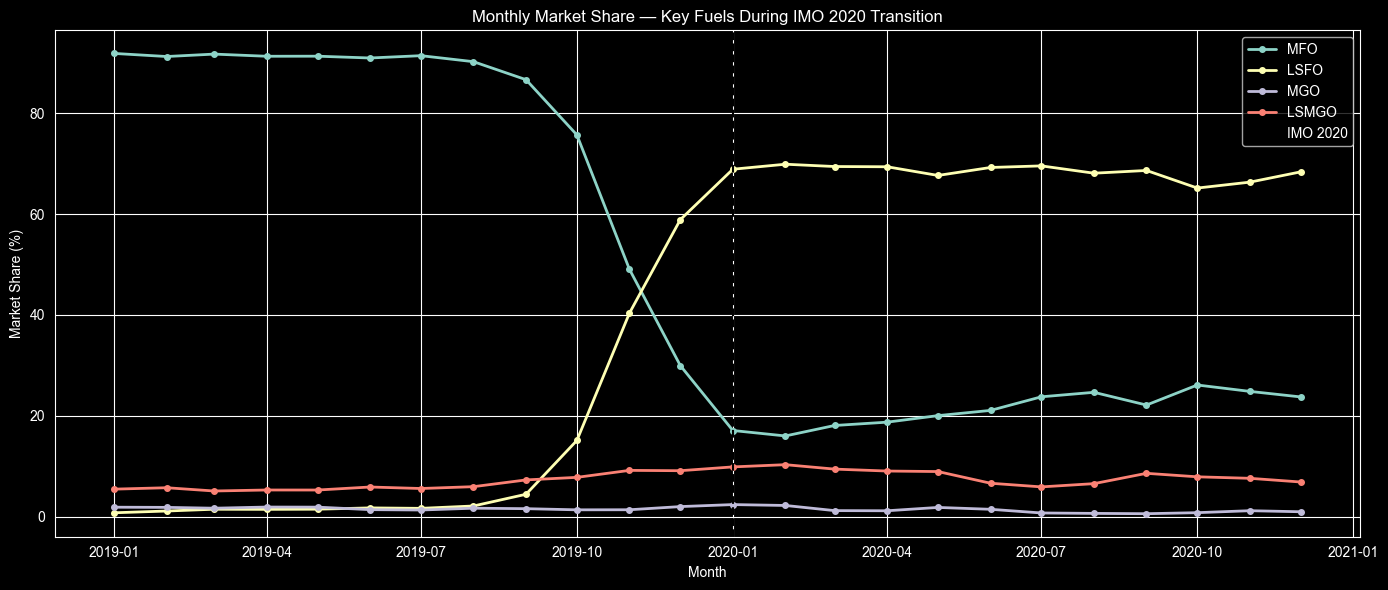

In [15]:
# Monthly drill-down: speed of the IMO 2020 transition (2019–2020)
monthly_imo = monthly_pivot.loc['2019':'2020']
monthly_pct = monthly_imo.div(monthly_imo.sum(axis=1), axis=0) * 100

# Focus on the key fuels that shifted
key_fuels = ["MFO", "LSFO", "MGO", "LSMGO"]
available = [f for f in key_fuels if f in monthly_pct.columns]

fig, ax = plt.subplots(figsize=(14, 6))
for fuel in available:
    ax.plot(monthly_pct.index, monthly_pct[fuel], marker="o", markersize=4, linewidth=2, label=fuel)

ax.axvline(pd.Timestamp("2020-01-01"), color="black", linestyle="--", linewidth=1.5, label="IMO 2020")
ax.set_xlabel("Month")
ax.set_ylabel("Market Share (%)")
ax.set_title("Monthly Market Share — Key Fuels During IMO 2020 Transition")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Fuel Transition Pairs — Substitution Dynamics

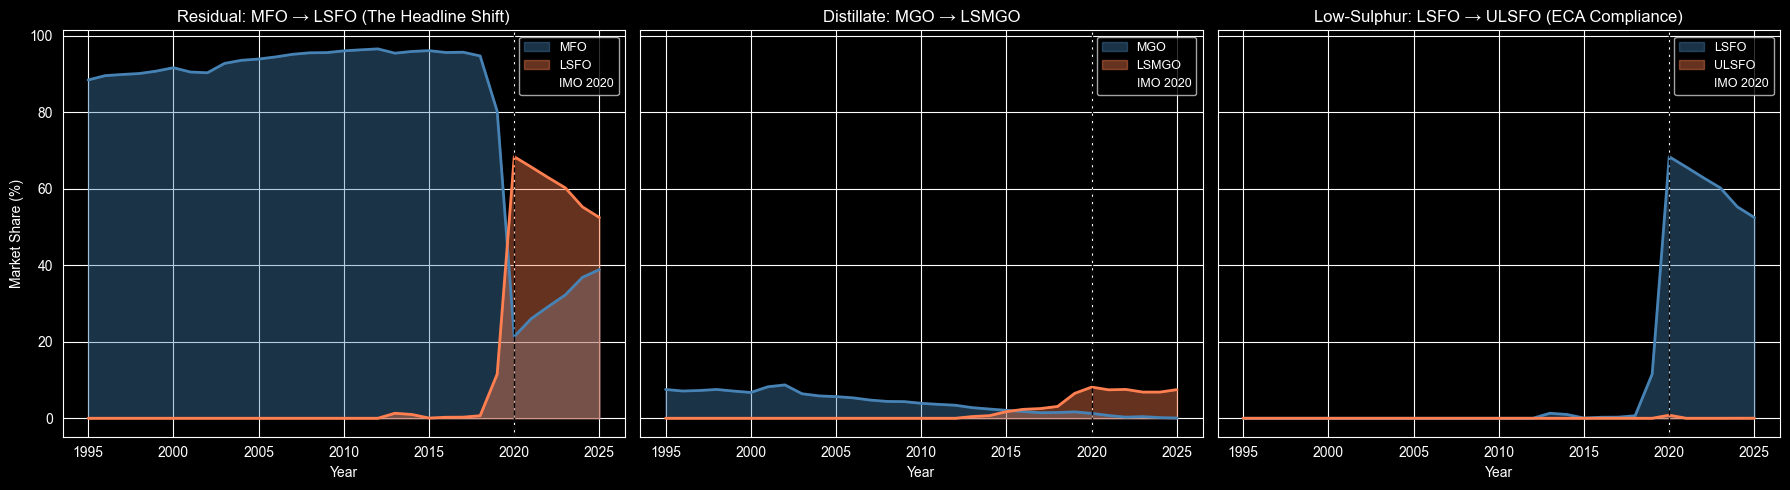

In [16]:
# Fuel transition pairs — annual market share over time
pairs = [
    ("MFO", "LSFO", "Residual: MFO → LSFO (The Headline Shift)"),
    ("MGO", "LSMGO", "Distillate: MGO → LSMGO"),
    ("LSFO", "ULSFO", "Low-Sulphur: LSFO → ULSFO (ECA Compliance)"),
]

pct = annual_wide.div(annual_wide.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (old, new, title) in zip(axes, pairs):
    if old in pct.columns:
        ax.fill_between(pct.index, pct[old], alpha=0.4, label=old, color="steelblue")
        ax.plot(pct.index, pct[old], color="steelblue", linewidth=2)
    if new in pct.columns:
        ax.fill_between(pct.index, pct[new], alpha=0.4, label=new, color="coral")
        ax.plot(pct.index, pct[new], color="coral", linewidth=2)
    ax.axvline(2020, color="black", linestyle="--", linewidth=1, label="IMO 2020")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.legend(loc="best", fontsize=9)

axes[0].set_ylabel("Market Share (%)")
plt.tight_layout()
plt.show()

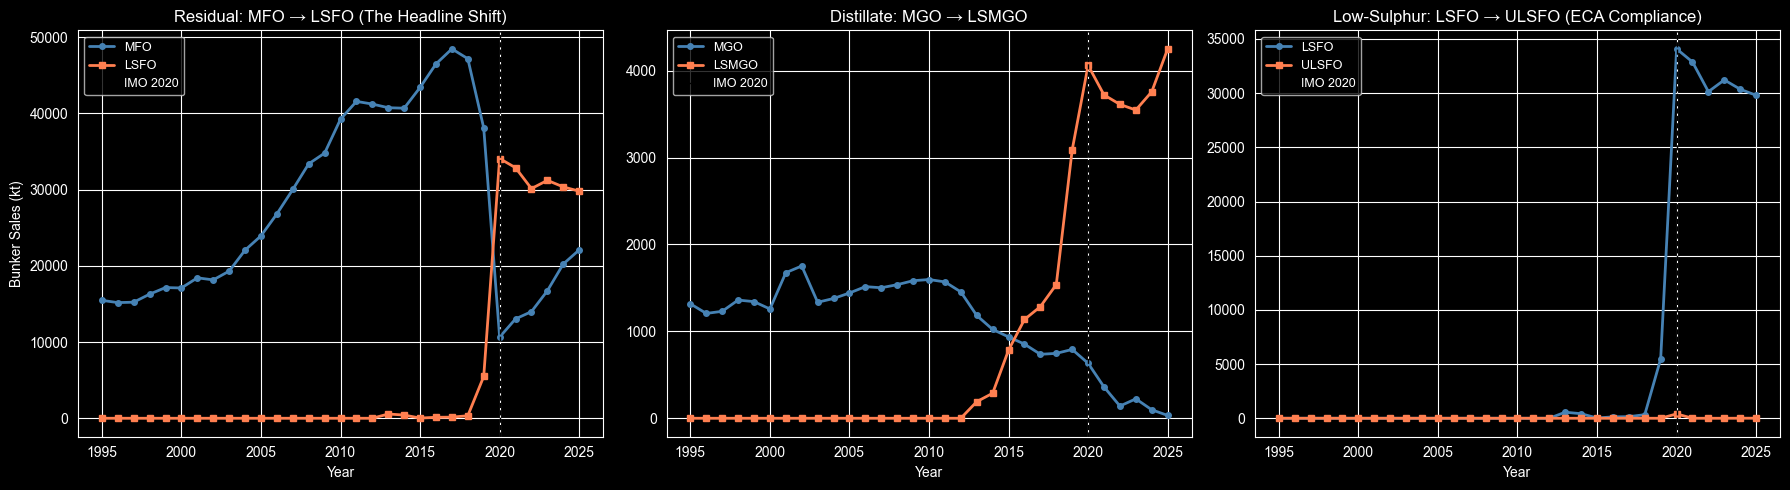

In [17]:
# Absolute volume comparison for each transition pair
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (old, new, title) in zip(axes, pairs):
    if old in annual_wide.columns:
        ax.plot(annual_wide.index, annual_wide[old], marker="o", markersize=4, linewidth=2, label=old, color="steelblue")
    if new in annual_wide.columns:
        ax.plot(annual_wide.index, annual_wide[new], marker="s", markersize=4, linewidth=2, label=new, color="coral")
    ax.axvline(2020, color="black", linestyle="--", linewidth=1, label="IMO 2020")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.legend(loc="best", fontsize=9)

axes[0].set_ylabel("Bunker Sales (kt)")
plt.tight_layout()
plt.show()

## 7. Key Findings Summary

In [18]:
# Generate key findings from the data
findings = []

# 1. MFO → LSFO headline shift
if "MFO" in compare.index and "LSFO" in compare.index:
    mfo_19 = compare.loc["MFO", "share_2019"]
    mfo_21 = compare.loc["MFO", "share_2021"]
    lsfo_19 = compare.loc["LSFO", "share_2019"]
    lsfo_21 = compare.loc["LSFO", "share_2021"]
    findings.append(
        f"**MFO → LSFO was the dominant IMO 2020 shift:** MFO dropped from {mfo_19:.1f}% to {mfo_21:.1f}% market share, "
        f"while LSFO surged from {lsfo_19:.1f}% to {lsfo_21:.1f}%."
    )

# 2. Overall market growth
total_19 = compare[2019].sum()
total_21 = compare[2021].sum()
growth = (total_21 / total_19 - 1) * 100
findings.append(
    f"**Total bunker market grew {growth:+.1f}% from 2019 to 2021** ({total_19:,.0f} kt → {total_21:,.0f} kt), "
    f"showing the regulation reshuffled the fuel mix without shrinking overall demand."
)

# 3. Distillate transition
if "MGO" in compare.index and "LSMGO" in compare.index:
    mgo_19 = compare.loc["MGO", "share_2019"]
    mgo_21 = compare.loc["MGO", "share_2021"]
    lsmgo_19 = compare.loc["LSMGO", "share_2019"]
    lsmgo_21 = compare.loc["LSMGO", "share_2021"]
    findings.append(
        f"**Distillate-tier shift mirrored the residual shift:** MGO fell from {mgo_19:.1f}% to {mgo_21:.1f}%, "
        f"replaced by LSMGO ({lsmgo_19:.1f}% → {lsmgo_21:.1f}%)."
    )

# 4. Speed of transition
findings.append(
    "**The transition was abrupt, not gradual:** Monthly data shows the MFO/LSFO crossover occurred "
    "almost entirely within Dec 2019–Jan 2020, indicating strong regulatory compliance."
)

# 5. LNG emergence
if "LNG" in compare.index:
    lng_19 = compare.loc["LNG", "share_2019"]
    lng_21 = compare.loc["LNG", "share_2021"]
    findings.append(
        f"**LNG is emerging but still marginal:** Market share grew from {lng_19:.1f}% to {lng_21:.1f}%, "
        f"suggesting early-stage adoption of alternative fuels alongside the sulphur-driven shifts."
    )

from IPython.display import Markdown, display
display(Markdown("\n".join(f"- {f}" for f in findings)))

- **MFO → LSFO was the dominant IMO 2020 shift:** MFO dropped from 80.3% to 26.0% market share, while LSFO surged from 11.5% to 65.7%.
- **Total bunker market grew +5.4% from 2019 to 2021** (47,464 kt → 50,040 kt), showing the regulation reshuffled the fuel mix without shrinking overall demand.
- **Distillate-tier shift mirrored the residual shift:** MGO fell from 1.7% to 0.7%, replaced by LSMGO (6.5% → 7.4%).
- **The transition was abrupt, not gradual:** Monthly data shows the MFO/LSFO crossover occurred almost entirely within Dec 2019–Jan 2020, indicating strong regulatory compliance.
- **LNG is emerging but still marginal:** Market share grew from 0.0% to 0.1%, suggesting early-stage adoption of alternative fuels alongside the sulphur-driven shifts.